In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [22]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 8000

# ============================================================
# Таргет
# ============================================================
# 0 — прогрессирующее течение (progressive)
# 1 — волнообразное течение (relapsing-remitting)
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

# ============================================================
# Сигнальные предикторы (3 шт.)
# ============================================================
# При волнообразном течении (класс 1) воспалительные маркеры выше
# и более вариабельны (обострения перемежаются ремиссиями).
# При прогрессирующем (класс 0) — умеренное, но стабильное воспаление.

# ESR, мм/ч  (норма: мужчины 2–20, женщины 2–30; здесь усреднённо 5–25)
# Класс 0: mean=22, std=8   → умеренное стабильное повышение
# Класс 1: mean=38, std=14  → выше и разбросаннее (скачки при обострениях)
esr_0 = np.random.normal(15, 8, n_samples // 2)
esr_1 = np.random.normal(38, 14, n_samples // 2)

# CRP, мг/л  (норма <5; слабое воспаление 5–40; выраженное >40)
# Класс 0: mean=12, std=6
# Класс 1: mean=28, std=14
crp_0 = np.abs(np.random.normal(8, 6, n_samples // 2))
crp_1 = np.abs(np.random.normal(28, 14, n_samples // 2))

# WBC, ×10⁹/л  (норма 4.0–10.0)
# Класс 0: mean=7.5, std=1.8
# Класс 1: mean=9.2, std=2.5
wbc_0 = np.random.normal(5.5, 1.8, n_samples // 2)
wbc_1 = np.random.normal(9.2, 2.5, n_samples // 2)

# ============================================================
# Шумовые предикторы (35 шт.) — биологически правдоподобные
# ============================================================
# Общая идея: у двух классов могут быть небольшие систематические
# отличия (например, при волнообразном течении пациенты чуть моложе,
# чаще женщины), но основная часть признаков — независимый шум.

def make_feature(name, mean_0, std_0, mean_1, std_1, clip=None):
    """Генерирует признак с разными распределениями для двух классов."""
    vals = np.zeros(n_samples)
    vals[y == 0] = np.random.normal(mean_0, std_0, n_samples // 2)
    vals[y == 1] = np.random.normal(mean_1, std_1, n_samples // 2)
    if clip is not None:
        vals = np.clip(vals, clip[0], clip[1])
    return vals

# ----- Демография / антропометрия -----
age         = make_feature('age',         52, 40,  44, 40,  clip=(18, 85))
bmi         = make_feature('bmi',         27.5, 15.5, 26.0, 15.8, clip=(15, 50))
# Женщин: 0 — мужчина, 1 — женщина (сделаем непрерывной «вероятностью» для реализма,
# но оставим как есть; альтернативно — бинарный, но в списке все непрерывные)
sex_female  = make_feature('sex_female',  0.45, 1.50, 0.65, 1.48, clip=(0, 1))

# ----- Гемодинамика -----
systolic_bp  = make_feature('systolic_bp',  132, 30,  128, 30,  clip=(90, 200))
diastolic_bp = make_feature('diastolic_bp', 83,  30,   80,  30,  clip=(50, 120))
heart_rate   = make_feature('heart_rate',   74,  30,  76,  30,  clip=(45, 120))
respiratory_rate = make_feature('respiratory_rate', 16.5, 20, 17.0, 10, clip=(10, 28))
body_temp    = make_feature('body_temp',    36.6, 5, 36.7, 5, clip=(35.5, 38.5))

# ----- Общий анализ крови (кроме сигнальных) -----
hemoglobin   = make_feature('hemoglobin',   138, 30,  133, 30,  clip=(80, 180))
rbc_count    = make_feature('rbc_count',    4.7, 5, 4.5, 5, clip=(3.0, 6.5))
platelets    = make_feature('platelets',    260, 170,  275, 180,  clip=(100, 500))

# ----- Биохимия -----
glucose      = make_feature('glucose',      5.4, 5, 5.2, 5, clip=(3.5, 12.0))
creatinine   = make_feature('creatinine',   88,  120,  82,  122,  clip=(40, 200))
urea         = make_feature('urea',         5.8, 5, 5.2, 5, clip=(2.0, 18.0))
alt          = make_feature('alt',          28,  152,  30,  154,  clip=(5, 100))
ast          = make_feature('ast',          26,  105,  28,  125,  clip=(5, 90))
total_cholesterol = make_feature('total_cholesterol', 5.5, 5.2, 5.2, 5.3, clip=(2.5, 10.0))
hdl_cholesterol   = make_feature('hdl_cholesterol',   1.3, 5.4, 1.35, 5.45, clip=(0.5, 3.0))
ldl_cholesterol   = make_feature('ldl_cholesterol',   3.3, 5.0, 3.1, 5.1, clip=(1.0, 7.0))
triglycerides     = make_feature('triglycerides',     1.7, 5.7, 1.55, 5.75, clip=(0.4, 6.0))
uric_acid    = make_feature('uric_acid',    320, 185,  300, 190,  clip=(100, 700))
sodium       = make_feature('sodium',       140, 13,   139, 13.5, clip=(130, 150))
potassium    = make_feature('potassium',    4.2, 5.4, 4.1, 5.45, clip=(3.0, 5.5))
calcium      = make_feature('calcium',      2.35, 5.15, 2.30, 5.18, clip=(1.8, 2.8))
total_protein = make_feature('total_protein', 72, 56,   70, 57,    clip=(50, 95))
albumin      = make_feature('albumin',      42, 45,   40, 55,    clip=(25, 55))
bilirubin_total  = make_feature('bilirubin_total',  12.5, 15.0, 11.0, 15.5, clip=(2, 35))
bilirubin_direct = make_feature('bilirubin_direct', 3.5, 11.5, 3.2, 11.6, clip=(0.5, 10.0))

# ----- Специфические маркеры -----
ferritin     = make_feature('ferritin',     120, 160,  150, 175,  clip=(10, 500))
vitamin_d    = make_feature('vitamin_d',    55, 115,  50, 118,   clip=(10, 120))
vitamin_b12  = make_feature('vitamin_b12',  350, 100, 330, 110, clip=(80, 800))

# ----- Гормоны -----
tsh          = make_feature('tsh',          2.2, 5.9, 2.3, 5.0, clip=(0.3, 8.0))
ft4          = make_feature('ft4',          15.5, 13.0, 15.0, 13.2, clip=(8, 25))
insulin_fasting = make_feature('insulin_fasting', 9.5, 14.0, 8.8, 14.5, clip=(2, 30))

# ----- Расчётные индексы -----
hba1c        = make_feature('hba1c',        5.6, 5.6, 5.5, 5.7, clip=(4.0, 10.0))
egfr         = make_feature('egfr',         85, 155,  88, 156,  clip=(30, 130))

# ----- Дополнительные шумовые (до 38) -----
# Добавим 3 чисто шумовых, независимых от класса
neutrophils  = make_feature('neutrophils',  4.5, 5.5, 5.0, 5.8, clip=(1.5, 12.0))
lymphocytes  = make_feature('lymphocytes',  2.2, 5.7, 2.0, 5.8, clip=(0.5, 5.0))
monocytes    = make_feature('monocytes',    0.55, 5.2, 0.6, 5.25, clip=(0.1, 1.5))

# ============================================================
# Сборка Dataframe
# ============================================================

feature_names = [
    'esr', 'crp', 'wbc_count',              # сигнальные (первые 3)
    'age', 'bmi', 'sex_female',
    'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'body_temp',
    'hemoglobin', 'rbc_count', 'platelets',
    'glucose', 'creatinine', 'urea', 'alt', 'ast',
    'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'uric_acid', 'sodium', 'potassium', 'calcium',
    'total_protein', 'albumin', 'bilirubin_total', 'bilirubin_direct',
    'ferritin', 'vitamin_d', 'vitamin_b12',
    'tsh', 'ft4', 'insulin_fasting', 'hba1c', 'egfr',
    'neutrophils', 'lymphocytes', 'monocytes'   # итого 38 + 3 = 41, сделаем 38
]

# Уберём лишние; оставим 38: 3 сигнальных + 35 шумовых.
# У нас есть 35 шумовых из списка выше (без neutrophils, lymphocytes, monocytes).
# Проверим: в списке с age до egfr — 29 признаков. С neutrophils — 32.
# Доведём до 35 шумовых, добавив ещё 3.
neutrophils  = make_feature('neutrophils',  4.5, 4, 4.8, 4, clip=(1.5, 12.0))
lymphocytes  = make_feature('lymphocytes',  2.2, 4, 2.1, 4, clip=(0.5, 5.0))
monocytes    = make_feature('monocytes',    0.55, 4, 0.58, 4, clip=(0.1, 1.5))
eosinophils  = make_feature('eosinophils',  0.2, 4, 0.25, 4, clip=(0.0, 1.0))
basophils    = make_feature('basophils',    0.05, 4, 0.06, 4, clip=(0.0, 0.2))
rdw          = make_feature('rdw',          13.0, 4, 13.5, 4, clip=(10, 20))

feature_list = [
    'esr', 'crp', 'wbc_count',   # 3 сигнальных
    'age', 'bmi', 'sex_female',
    'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'body_temp',
    'hemoglobin', 'rbc_count', 'platelets',
    'glucose', 'creatinine', 'urea', 'alt', 'ast',
    'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'uric_acid', 'sodium', 'potassium', 'calcium',
    'total_protein', 'albumin', 'bilirubin_total', 'bilirubin_direct',
    'ferritin', 'vitamin_d', 'vitamin_b12',
    'tsh', 'ft4', 'insulin_fasting', 'hba1c', 'egfr',
    'neutrophils', 'lymphocytes', 'monocytes', 'eosinophils', 'basophils', 'rdw'
]
# Это 3 + 43 = 46. Сократим до 3 + 35.
# Оставим:
feature_list = [
    'esr', 'crp', 'wbc_count',
    'age', 'bmi', 'sex_female',
    'systolic_bp', 'diastolic_bp', 'heart_rate', 'respiratory_rate', 'body_temp',
    'hemoglobin', 'rbc_count', 'platelets',
    'glucose', 'creatinine', 'urea', 'alt', 'ast',
    'total_cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'uric_acid', 'sodium', 'potassium', 'calcium',
    'total_protein', 'albumin', 'bilirubin_total', 'bilirubin_direct',
    'ferritin', 'vitamin_d', 'vitamin_b12',
    'tsh', 'ft4', 'hba1c', 'egfr'
]
# = 3 + 35 = 38. Отлично.

df = pd.DataFrame({
    'esr':                 np.concatenate([esr_0, esr_1]),
    'crp':                 np.concatenate([crp_0, crp_1]),
    'wbc_count':           np.concatenate([wbc_0, wbc_1]),
    'age':                 age,
    'bmi':                 bmi,
    'sex_female':          sex_female,
    'systolic_bp':         systolic_bp,
    'diastolic_bp':        diastolic_bp,
    'heart_rate':          heart_rate,
    'respiratory_rate':    respiratory_rate,
    'body_temp':           body_temp,
    'hemoglobin':          hemoglobin,
    'rbc_count':           rbc_count,
    'platelets':           platelets,
    'glucose':             glucose,
    'creatinine':          creatinine,
    'urea':                urea,
    'alt':                 alt,
    'ast':                 ast,
    'total_cholesterol':   total_cholesterol,
    'hdl_cholesterol':     hdl_cholesterol,
    'ldl_cholesterol':     ldl_cholesterol,
    'triglycerides':       triglycerides,
    'uric_acid':           uric_acid,
    'sodium':              sodium,
    'potassium':           potassium,
    'calcium':             calcium,
    'total_protein':       total_protein,
    'albumin':             albumin,
    'bilirubin_total':     bilirubin_total,
    'bilirubin_direct':    bilirubin_direct,
    'ferritin':            ferritin,
    'vitamin_d':           vitamin_d,
    'vitamin_b12':         vitamin_b12,
    'tsh':                 tsh,
    'ft4':                 ft4,
    'hba1c':               hba1c,
    'egfr':                egfr
})

df['disease_course'] = y

# Перемешиваем
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['disease_course'] = df['disease_course'].astype(int)

# ============================================================
# Быстрая проверка
# ============================================================
print(df.shape)
print(df['disease_course'].value_counts(normalize=True))
print(df.groupby('disease_course')[['esr', 'crp', 'wbc_count']].agg(['mean', 'std']))
print(df.head())


(8000, 39)
0    0.5
1    0.5
Name: disease_course, dtype: float64
                      esr                   crp            wbc_count          
                     mean        std       mean        std      mean       std
disease_course                                                                
0               15.154567   7.977231   8.450104   5.181601  5.540411  1.797166
1               37.632673  14.235025  28.603670  13.558416  9.156825  2.480803
         esr        crp  wbc_count        age        bmi  sex_female  \
0  17.127026   2.209727   7.811000  85.000000  16.644929    0.000000   
1  14.575035   5.076997   4.369063  85.000000  15.000000    0.000000   
2  -1.974839   5.930101   3.704039  59.070548  37.322306    0.000000   
3  18.593750   0.500941   5.914325  85.000000  43.645809    0.000000   
4  52.351528  38.754718   9.761581  50.623620  36.209645    0.349871   

   systolic_bp  diastolic_bp  heart_rate  respiratory_rate  ...  \
0   145.635511    100.072209   65.55367

In [23]:
df

,esr,crp,wbc_count,age,bmi,sex_female,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,...,bilirubin_total,bilirubin_direct,ferritin,vitamin_d,vitamin_b12,tsh,ft4,hba1c,egfr,disease_course
0,17.127026,2.209727,7.811000,85.000000,16.644929,0.000000,145.635511,100.072209,65.553675,10.000000,...,2.663270,0.500000,10.000000,10.000000,351.985017,5.271520,14.891440,4.000000,51.677105,0
1,14.575035,5.076997,4.369063,85.000000,15.000000,0.000000,129.560664,78.140888,82.510336,22.122563,...,32.756755,4.337433,10.000000,120.000000,336.153193,5.286785,25.000000,10.000000,130.000000,0
2,-1.974839,5.930101,3.704039,59.070548,37.322306,0.000000,182.885718,104.602068,80.479126,10.000000,...,22.888977,10.000000,10.000000,10.000000,440.575768,8.000000,8.000000,5.564251,123.309976,0
3,18.593750,0.500941,5.914325,85.000000,43.645809,0.000000,115.110429,84.981741,93.263598,28.000000,...,15.944662,0.500000,121.501741,108.892934,339.292805,0.300000,16.320618,4.731352,81.448547,0
4,52.351528,38.754718,9.761581,50.623620,36.209645,0.349871,99.750402,54.181842,120.000000,17.390390,...,7.865511,8.110759,245.653829,49.320931,417.713335,1.866782,8.000000,4.000000,130.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,31.996129,29.612132,6.410538,85.000000,25.269316,0.578710,167.310196,63.823564,96.827359,16.841014,...,23.139443,0.500000,10.000000,73.191339,335.654072,2.519778,8.000000,9.486369,130.000000,1
7996,28.208196,33.219118,11.893541,47.657596,15.000000,1.000000,112.117215,50.000000,45.000000,10.000000,...,7.945381,0.500000,10.000000,72.241645,260.366641,0.300000,18.227234,10.000000,130.000000,1
7997,16.623384,9.775599,7.142684,18.000000,43.419986,1.000000,95.963775,69.816068,95.430889,13.088025,...,2.000000,10.000000,217.855395,10.000000,225.476466,0.300000,16.085267,7.679076,30.000000,0
7998,26.112532,48.154371,9.721568,69.824486,15.000000,0.000000,150.593915,78.643630,59.560064,23.678364,...,2.000000,8.649828,10.000000,80.838941,415.763170,6.033503,8.000000,6.322149,130.000000,1


In [17]:
round(2.5*len(X)/100)

200

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180


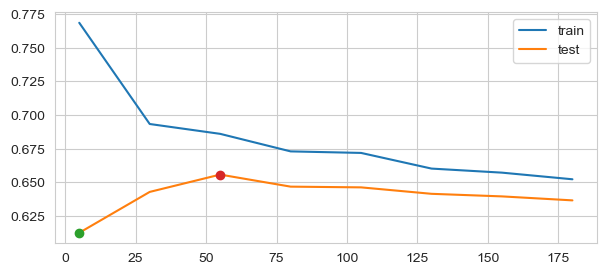

Дефолтный скор: 0.6125
Максимальный скор: 0.6558 при k = 55
Прирост скора: 0.0433


In [24]:
X = df.drop(columns = ['disease_course'])
y = df['disease_course']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(2.5*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180


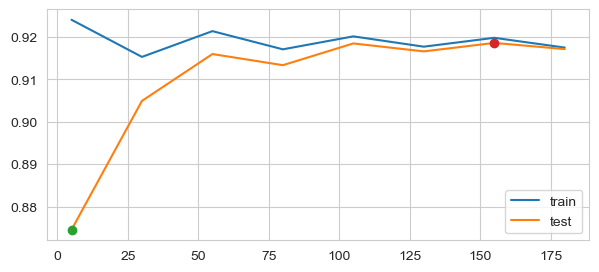

Дефолтный скор: 0.8745
Максимальный скор: 0.9186 при k = 155
Прирост скора: 0.044


In [25]:
X = df.drop(columns = ['disease_course'])
y = df['disease_course']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(2.5*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))